In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [31]:
df = pd.read_csv("./청년정책목록_전체.csv", encoding="utf-8")

# 사업기간

In [33]:
# 사업기간구분코드, 사업기간시작일자, 사업기간종료일자, 사업기간기타내용
df[['bizPrdSeCd', 'bizPrdBgngYmd', 'bizPrdEndYmd', 'bizPrdEtcCn']]

,bizPrdSeCd,bizPrdBgngYmd,bizPrdEndYmd,bizPrdEtcCn
0,56002.0,,,연중
1,56001.0,20250101,20251231,NaN
2,56001.0,20250101,20251231,NaN
3,56001.0,20250101,20251231,NaN
4,56001.0,20250101,20251231,NaN
...,...,...,...,...
3453,NaN,NaN,NaN,상시
3454,NaN,NaN,NaN,상시
3455,NaN,NaN,NaN,2013년~계속
3456,NaN,20230725,20281231,2023-07-25~2028-12-31


In [42]:
# 사업기간 결측치
df[['bizPrdSeCd', 'bizPrdBgngYmd', 'bizPrdEndYmd', 'bizPrdEtcCn']].isnull().sum()

bizPrdSeCd       2839
bizPrdBgngYmd    2701
bizPrdEndYmd     2701
bizPrdEtcCn      1650
dtype: int64

In [41]:
# 사업기간 결측치 비율
df[['bizPrdSeCd', 'bizPrdBgngYmd', 'bizPrdEndYmd', 'bizPrdEtcCn']].isnull().sum() / len(df)

bizPrdSeCd       0.820995
bizPrdBgngYmd    0.781087
bizPrdEndYmd     0.781087
bizPrdEtcCn      0.477154
dtype: float64

bizPrdEtcCn 결측치 수: 1650
bizPrdEtcCn 값이 있는 데이터 수: 1808


C:\Users\Playdata\AppData\Local\Temp\ipykernel_22116\2678926463.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['bizPrdEtcCn'].isnull(), palette='viridis')


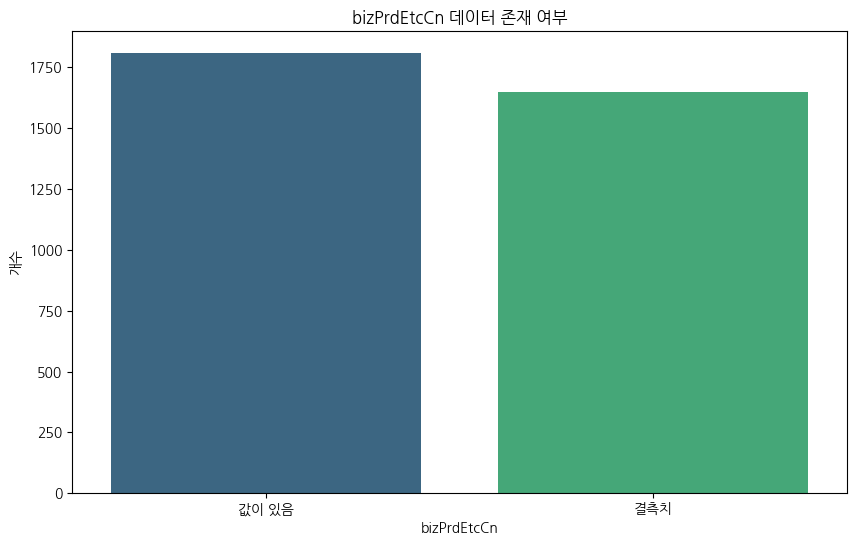


가장 많이 등장하는 값 (상위 10개):
bizPrdEtcCn
-                            818
상시                            54
2024.01.01.~2024.12.31.       33
연중                            31
2024. 1. ~ 12.                22
2024-01-01~2024-12-31         13
2024-03-01~2024-12-31         13
담당자 문의                        11
○ 사업기간 : '24. 1. ~ 12.        11
□ 2024.01.01.~2024.12.31.     11
Name: count, dtype: int64


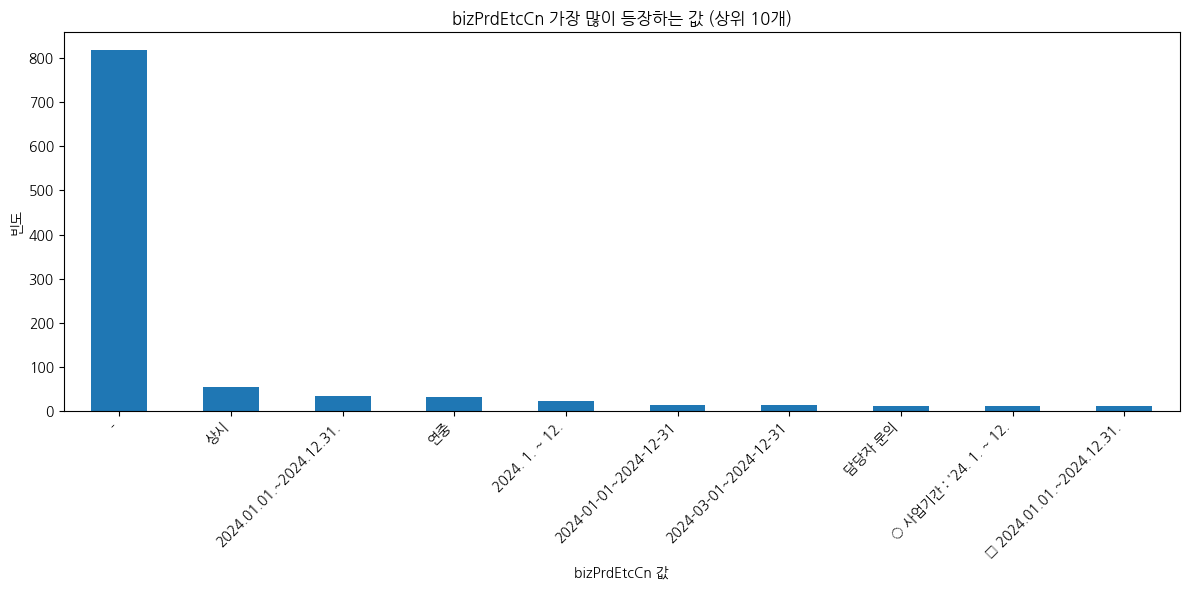

In [74]:
# bizPrdEtcCn 데이터의 카운트플롯 그리기

# 결측치 여부 확인
null_count = df['bizPrdEtcCn'].isnull().sum()
not_null_count = len(df) - null_count
print(f"bizPrdEtcCn 결측치 수: {null_count}")
print(f"bizPrdEtcCn 값이 있는 데이터 수: {not_null_count}")

# 결측치/비결측치 분포 시각화
plt.figure(figsize=(10, 6))
sns.countplot(x=df['bizPrdEtcCn'].isnull(), palette='viridis')
plt.xticks([0, 1], ['값이 있음', '결측치'])
plt.title('bizPrdEtcCn 데이터 존재 여부')
plt.ylabel('개수')
plt.show()

# 가장 많이 등장하는 값 보기 (상위 10개)
if not_null_count > 0:
    top_values = df['bizPrdEtcCn'].value_counts().head(10)
    print("\n가장 많이 등장하는 값 (상위 10개):")
    print(top_values)
    
    plt.figure(figsize=(12, 6))
    top_values.plot(kind='bar')
    plt.title('bizPrdEtcCn 가장 많이 등장하는 값 (상위 10개)')
    plt.ylabel('빈도')
    plt.xlabel('bizPrdEtcCn 값')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [63]:
# 신청기간 결측치 비율
print(f'신청기간 결측치:{df['aplyYmd'].isnull().sum()}, 결측치 비율:{df['aplyYmd'].isnull().sum() / len(df)}')

신청기간 결측치:1139, 결측치 비율:0.32938114517061884


# 신청, URL

In [ ]:
# 신청URL주소, 신청기간, 참고URL주소1, 참고URL주소2
df[['aplyUrlAddr', 'aplyYmd', 'refUrlAddr1', 'refUrlAddr2']]

,aplyUrlAddr,aplyYmd,refUrlAddr1,refUrlAddr2
0,https://www.kosaf.go.kr/ko/scholar.do?pg=schol...,20250523 ~ 20250623,https://www.kosaf.go.kr/ko/scholar.do?pg=schol...,NaN
1,https://busan.pass.or.kr/support/sub6.php,NaN,NaN,NaN
2,NaN,20250201 ~ 20250930\N20250414 ~ 20250417,https://youth.seoul.go.kr/youthConts.do?key=23...,NaN
3,https://account.welfare.seoul.kr,20250609 ~ 20250620,https://youth.seoul.go.kr/content.do?key=23101...,NaN
4,https://youth.seoul.go.kr/youngtech/main,20250301 ~ 20251130,NaN,NaN
...,...,...,...,...
3453,https://www.kdream.or.kr/user/index.asp,NaN,https://www.kdream.or.kr:446/user/index.asp,NaN
3454,http://nhuf.molit.go.kr/FP/FP05/FP0502/FP05020...,NaN,http://nhuf.molit.go.kr/FP/FP05/FP0502/FP05020...,https://www.seoulhousing.kr/html/0504002.do
3455,https://ipsi.ict.ac.kr/content/jungsi07,NaN,https://ipsi.ict.ac.kr/content/susi01_01,https://ipsi.ict.ac.kr/home/main
3456,http://gbyouth.co.kr/policy/list.tc?mn=2379&pa...,NaN,http://gbyouth.co.kr/policy/list.tc?mn=2379&pa...,NaN


In [75]:
# aplyUrlAddr과 refUrlAddr1이 같은 데이터 개수 확인
same_url_count = sum(df['aplyUrlAddr'] == df['refUrlAddr1'])

# 결과 출력
print(f"aplyUrlAddr과 refUrlAddr1이 동일한 행의 개수: {same_url_count}")
print(f"전체 데이터 중 비율: {same_url_count / len(df) * 100:.2f}%")

# 결측치 고려하지 않고 두 컬럼이 모두 값이 있는 경우만 비교
non_null_rows = df.dropna(subset=['aplyUrlAddr', 'refUrlAddr1'])
same_url_non_null = sum(non_null_rows['aplyUrlAddr'] == non_null_rows['refUrlAddr1'])

print(f"\n두 컬럼 모두 값이 있는 행 중 동일한 URL을 가진 행의 개수: {same_url_non_null}")
print(f"두 컬럼 모두 값이 있는 행 중 비율: {same_url_non_null / len(non_null_rows) * 100:.2f}%")

# 샘플 데이터 확인 (동일한 URL 가진 처음 5개 행)
same_url_df = df[df['aplyUrlAddr'] == df['refUrlAddr1']].head(5)
print("\n동일한 URL을 가진 행의 샘플 데이터:")
display(same_url_df[['plcyNm', 'aplyUrlAddr', 'refUrlAddr1']])

aplyUrlAddr과 refUrlAddr1이 동일한 행의 개수: 281
전체 데이터 중 비율: 8.13%

두 컬럼 모두 값이 있는 행 중 동일한 URL을 가진 행의 개수: 281
두 컬럼 모두 값이 있는 행 중 비율: 25.07%

동일한 URL을 가진 행의 샘플 데이터:


,plcyNm,aplyUrlAddr,refUrlAddr1
28,청년정책 서포터즈 [광주 청년톡파원] 1기,https://youth.gwangju.go.kr/,https://youth.gwangju.go.kr/
38,청년 자격시험 등 응시료 지원,https://www.ulsan.go.kr/s/ulsanyouth/contents....,https://www.ulsan.go.kr/s/ulsanyouth/contents....
57,2025년 달서청년 자격증 응시료 지원사업,https://www.dalseo.daegu.kr/index.do?menu_id=0...,https://www.dalseo.daegu.kr/index.do?menu_id=0...
69,청년농업인 영농정착 지원,https://uni.agrix.go.kr/webportal/main/portalI...,https://uni.agrix.go.kr/webportal/main/portalI...
79,의왕시 청년옷장(면접정장 무료대여서비스),https://apply.jobaba.net/bsns/bsnsDetailView.d...,https://apply.jobaba.net/bsns/bsnsDetailView.d...


# 정책신청방법내용, 심사방법내용, 제출서류내용, 기타사항내용

In [37]:
# 정책신청방법내용, 심사방법내용, 제출서류내용, 기타사항내용
df[['plcyAplyMthdCn', 'srngMthdCn', 'sbmsnDcmntCn', 'etcMttrCn']]

,plcyAplyMthdCn,srngMthdCn,sbmsnDcmntCn,etcMttrCn
0,□ 2학기 신청일정: 2025. 5. 23.(금) 9시 ~ 6. 23.(월) 18시...,□ 선발결과 공개일: 10월 4 ~ 5주 예정\n- 선발결과 공개일은 재단 및 유관...,한국장학재단 홈페이지(https://www.kosaf.go.kr/ko/scholar...,NaN
1,부산사회서비스원 홈페이지온라인 신청\n○ 고립은둔 청년 지원 신청 : https:/...,NaN,"대상자 선정을 위해 필요한 추가서류 요청\n\n가족돌봄 청(소)년의 경우,\n① (...",NaN
2,"총 4차(1월, 4월, 6월, 9월)에 걸쳐 참여자를 모집하며, 연도내 중복참여는 ...",NaN,NaN,ㅇ (사업 근거)\n - 청년기본법 제21조(청년 복지증진)\n - 서울특별...
3,□ 신청기간 : 2025. 6. 9.(월) ~ 6. 20.(금) 18:00 ※ 신청...,NaN,NaN,ㅇ (사업 근거)\n - 「서울특별시 주민생활안정 지원에 관한 조례」제4ㆍ5조 ...
4,NaN,NaN,정보제공 동의(주민등록등본 정보 제공 : 서울시 거주 여부) 하신 경우 별도의 신청...,ㅇ 사업 근거\n - 청년기본법 제22조(청년 금융생활 지원)\n - 서울시...
...,...,...,...,...
3453,꿈드림 누리집(www.kdream.or.kr) 검색을 통해 지역별 학교밖청소년지원센...,-,- 건강검진신청서(개인정보 수집·이용동의서 1부)\n- 본인임을 증빙할 수 있는 서...,"[문의] \n청소년상담 1388, 휴대전화 시 국번+1388"
3454,대출조건 확인 ▷ 대출신청 ▷ 자산심사 ▷ 자산심사 결과 정보 송신 ▷ 서류제출 및...,-,"신분증, 주민등록등본, 소득확인서류, 건강보험득실확인서, 확정일자부 임대차(전세)계...",[유의사항]\n- 대출 취급 후 주택취득이 확인된 경우에는 본 대출금을 상환하여야 ...
3455,ㅇICT 폴리텍 신입생 수시모집 및 정시모집 공고 확인 후 절차에 맞추어 지원\n①...,-,공통 사항: 응시원서(우리 대학 소정양식) 1부 고등학교 생활기록부 사본 1부(20...,○ 문의\n정보통신기획평가원 전략기획본부 디지털인재양성단 디지털인재기획팀\n\n- ...
3456,"주소지 읍면동 방문, 온라인",-,신청서,-


In [38]:
df[['plcyAplyMthdCn', 'srngMthdCn', 'sbmsnDcmntCn', 'etcMttrCn']].isnull().sum()

plcyAplyMthdCn     532
srngMthdCn        1414
sbmsnDcmntCn      1232
etcMttrCn         1283
dtype: int64

In [114]:
# 기타사항내용
df['etcMttrCn']

0                                                     NaN
1                                                     NaN
2       ㅇ (사업 근거)\n   - 청년기본법 제21조(청년 복지증진)\n   - 서울특별...
3       ㅇ (사업 근거)\n   - 「서울특별시 주민생활안정 지원에 관한 조례」제4ㆍ5조 ...
4       ㅇ 사업 근거\n   - 청년기본법 제22조(청년 금융생활 지원)\n   - 서울시...
                              ...                        
3453                    [문의] \n청소년상담 1388, 휴대전화 시 국번+1388
3454    [유의사항]\n- 대출 취급 후 주택취득이 확인된 경우에는 본 대출금을 상환하여야 ...
3455    ○ 문의\n정보통신기획평가원 전략기획본부 디지털인재양성단 디지털인재기획팀\n\n- ...
3456                                                    -
3457                                                    -
Name: etcMttrCn, Length: 3458, dtype: object

# 지원

In [ ]:
# 지원규모수, 지원도착순서여부(선착순), 지원대상최소연령, 지원대상최대연령, 지원대상연령제한여부, 결혼상태코드
df[['sprtSclCnt', 'sprtArvlSeqYn', 'sprtTrgtMinAge', 'sprtTrgtMaxAge', 'sprtTrgtAgeLmtYn', 'mrgSttsCd' ]]

,sprtSclCnt,sprtArvlSeqYn,sprtTrgtMinAge,sprtTrgtMaxAge,sprtTrgtAgeLmtYn,mrgSttsCd
0,0.0,N,0.0,39.0,N,55002.0
1,0.0,N,18.0,39.0,N,55003.0
2,11000.0,N,19.0,39.0,N,55003.0
3,10000.0,N,18.0,34.0,N,55003.0
4,0.0,N,19.0,39.0,N,55003.0
...,...,...,...,...,...,...
3453,NaN,N,9.0,24.0,N,NaN
3454,NaN,N,19.0,34.0,N,NaN
3455,192.0,N,NaN,NaN,Y,NaN
3456,NaN,N,NaN,NaN,Y,NaN


In [78]:
# 결측치 확인
df[['sprtSclCnt', 'sprtArvlSeqYn', 'sprtTrgtMinAge', 'sprtTrgtMaxAge', 'sprtTrgtAgeLmtYn', 'mrgSttsCd']].isnull().sum()

sprtSclCnt          2047
sprtArvlSeqYn          0
sprtTrgtMinAge      1005
sprtTrgtMaxAge      1068
sprtTrgtAgeLmtYn       0
mrgSttsCd           2820
dtype: int64

In [83]:
# 지원대상연령제한여부
df['sprtTrgtAgeLmtYn'].value_counts()

sprtTrgtAgeLmtYn
N    2279
Y    1179
Name: count, dtype: int64

In [95]:
df[df['sprtTrgtAgeLmtYn'] == 'Y'][['sprtTrgtMinAge', 'sprtTrgtMaxAge']]

,sprtTrgtMinAge,sprtTrgtMaxAge
20,0.0,0.0
32,0.0,0.0
35,0.0,0.0
44,0.0,0.0
58,0.0,0.0
...,...,...
3446,NaN,NaN
3447,NaN,NaN
3452,NaN,NaN
3455,NaN,NaN


In [96]:
df[df['sprtTrgtAgeLmtYn'] == 'Y'][['sprtTrgtMinAge', 'sprtTrgtMaxAge']].isnull().sum()

sprtTrgtMinAge    1004
sprtTrgtMaxAge    1004
dtype: int64

In [93]:
df[df['sprtTrgtAgeLmtYn'] == 'N'][['sprtTrgtMinAge', 'sprtTrgtMaxAge']]

,sprtTrgtMinAge,sprtTrgtMaxAge
0,0.0,39.0
1,18.0,39.0
2,19.0,39.0
3,18.0,34.0
4,19.0,39.0
...,...,...
3450,9.0,24.0
3451,9.0,24.0
3453,9.0,24.0
3454,19.0,34.0


In [94]:
df[df['sprtTrgtAgeLmtYn'] == 'N'][['sprtTrgtMinAge', 'sprtTrgtMaxAge']].isnull().sum()

sprtTrgtMinAge     1
sprtTrgtMaxAge    64
dtype: int64

In [91]:
# sprtTrgtAgeLmtYn이 'Y'인 경우: 제한 없음 'N'인 경우: 제한 있음

# 소득

In [98]:
# 소득조건구분코드, 소득최소금액, 소득최대금액, 소득기타내용
df[['earnCndSeCd', 'earnMinAmt', 'earnMaxAmt', 'earnEtcCn']]

,earnCndSeCd,earnMinAmt,earnMaxAmt,earnEtcCn
0,43003.0,0.0,0.0,기초생활수급자 또는 차상위계층
1,43003.0,0.0,0.0,신청페이지 상세안내 확인
2,43001.0,0.0,0.0,NaN
3,43003.0,0.0,0.0,"-본인소득 : 세전 월 255만원 이하, 부양의무자: 고소득(1억원), 고재산(9억..."
4,43001.0,0.0,0.0,NaN
...,...,...,...,...
3453,NaN,NaN,NaN,NaN
3454,NaN,NaN,NaN,NaN
3455,NaN,NaN,NaN,NaN
3456,NaN,NaN,NaN,NaN


In [99]:
# 결측치
df[['earnCndSeCd', 'earnMinAmt', 'earnMaxAmt', 'earnEtcCn']].isnull().sum()

earnCndSeCd    2843
earnMinAmt     2878
earnMaxAmt     2878
earnEtcCn      3361
dtype: int64

In [100]:
# 결측치 비율
df[['earnCndSeCd', 'earnMinAmt', 'earnMaxAmt', 'earnEtcCn']].isnull().sum() / len(df)

earnCndSeCd    0.822152
earnMinAmt     0.832273
earnMaxAmt     0.832273
earnEtcCn      0.971949
dtype: float64

In [ ]:
# 가설: 소득 데이터가 없는 경우 소득조건이 없는 경우이다

In [103]:
df.iloc[3453]

plcyNo                                            20240104005400100003
bscPlanCycl                                                          1
bscPlanPlcyWayNo                                                     4
bscPlanFcsAsmtNo                                                    15
bscPlanAsmtNo                                                       40
pvsnInstGroupCd                                                  54001
plcyPvsnMthdCd                                                     NaN
plcyAprvSttsCd                                                   44002
plcyNm                                                   학교 밖 청소년 건강검진
plcyKywdNm                                                         NaN
plcyExplnCn          학교 밖 청소년이 건강하게 성장할 수 있도록 지원하기 위하여 학교 밖 청소년을 대상...
lclsfNm                                                      복지문화,복지문화
mclsfNm                                                 취약계층 및 금융지원,건강
plcySprtCn           (1) 검진항목 : 상담 및 진찰, 신체 계측, 혈액검사, 소변검사, 구강검진 등\...
sprvsn

In [104]:
df.iloc[2]

plcyNo                                            20250519005400210855
bscPlanCycl                                                          1
bscPlanPlcyWayNo                                                     4
bscPlanFcsAsmtNo                                                    15
bscPlanAsmtNo                                                       39
pvsnInstGroupCd                                                  54002
plcyPvsnMthdCd                                                 42005.0
plcyAprvSttsCd                                                   44002
plcyNm                                                 서울 청년 마음건강 지원사업
plcyKywdNm                                                    맞춤형상담서비스
plcyExplnCn                            우울·불안 등 정서적 어려움을 겪는 청년의 마음건강 회복
lclsfNm                                                           복지문화
mclsfNm                                                             건강
plcySprtCn            ㅇ (사업 내용) 2단계 선별검사로 과학적 진단을 통한 맞춤형 상담 지원\n   ...
sprvsn

In [107]:
df['addAplyQlfcCndCn']

0       □ 학생 지원자격\n○ 대한민국 국적을 소지하고 재학 중인 대학생(대학원생 제외)\...
1       1.고립·은둔 청년 지원\n○ 정 의 : 힘들 때 기댈 사람이 없거나, 집(방)에서...
2       만 19세~39세 서울 거주 청년 중 심리지원이 필요한 청년(1985년생~2006년...
3                                                     NaN
4        ㅇ 재무상담 : 신청일자 기준으로 서울시에 주소지가 등록되어 있는 만 19~39세...
                              ...                        
3453                                                    -
3454    □ 신청 시기\n ○ 임대차계약서상 잔금지급일과 주민등록등본상 전입일 중 빠른 날로...
3455    ㅇ학과별 모집정원의 30퍼센트 범위 내에서 아래 해당자에 대해 우선 선발\n- 기초...
3456                                                    -
3457                                                    -
Name: addAplyQlfcCndCn, Length: 3458, dtype: object

In [109]:
df['addAplyQlfcCndCn'].isnull().sum()

np.int64(1494)

In [110]:
df['ptcpPrpTrgtCn']

0                                                     NaN
1                                                     NaN
2                                                     NaN
3                                                     NaN
4                                                     NaN
                              ...                        
3453                                                    -
3454    (공공임대주택) 대출접수일 현재 공공임대주택에 입주하고 있는 경우 불가\n ※ 대출...
3455                                                 제한없음
3456                                   관외 거주, 관외 소재 학교 학생
3457                                          강릉시 홈페이지 확인
Name: ptcpPrpTrgtCn, Length: 3458, dtype: object

# 조건

In [112]:
# 정책거주지역코드, 정책전공요건코드, 정책취업요건코드, 정책학력요건코드
df[['zipCd', 'plcyMajorCd', 'jobCd', 'schoolCd']] 

,zipCd,plcyMajorCd,jobCd,schoolCd
0,"11110,11140,11170,11200,11215,11230,11260,1129...",0011009,0013010,0049005
1,"26110,26140,26170,26200,26230,26260,26290,2632...",0011009,0013010,0049010
2,"11110,11140,11170,11200,11215,11230,11260,1129...",0011009,0013010,0049010
3,"11110,11140,11170,11200,11215,11230,11260,1129...",0011009,0013001,0049010
4,"11110,11140,11170,11200,11215,11230,11260,1129...",0011009,0013010,0049010
...,...,...,...,...
3453,"11110,11140,11170,11200,11215,11230,11260,1129...",0011009,0013010,0049010
3454,"11110,11140,11170,11200,11215,11230,11260,1129...",0011009,"0013001,0013006",0049010
3455,"11110,11140,11170,11200,11215,11230,11260,1129...",0011009,0013010,"0049003,0049004"
3456,47190,0011009,0013010,"0049002,0049003,0049005,0049006"


In [113]:
df[['zipCd', 'plcyMajorCd', 'jobCd', 'schoolCd']].isnull().sum()

zipCd          0
plcyMajorCd    0
jobCd          0
schoolCd       0
dtype: int64

In [ ]:
df[['zipCd', 'plcyMajorCd', 'jobCd', 'schoolCd']] 

정책거주지역코드(zipCd) 빈도:


,값,빈도
0,11680,496
1,11620,495
2,11170,495
3,11320,494
4,11305,493
5,11350,492
6,11710,491
7,11740,490
8,11380,490
9,11650,490



정책전공요건코드(plcyMajorCd) 빈도:


,값,빈도
0,0011009,3322
1,0011005,102
2,0011004,95
3,0011006,89
4,0011007,87
5,0011002,82
6,0011001,82
7,0011003,81
8,0011008,22



정책취업요건코드(jobCd) 빈도:


,값,빈도
0,0013010,2392
1,0013003,577
2,0013006,354
3,0013002,198
4,0013001,193
5,0013008,135
6,0013005,120
7,0013004,113
8,0013007,107
9,0013009,34



정책학력요건코드(schoolCd) 빈도:


,값,빈도
0,0049010,3014
1,0049005,304
2,0049006,238
3,0049007,212
4,0049004,178
5,0049008,173
6,0049003,133
7,0049001,117
8,0049002,105
9,0049009,27


C:\Users\Playdata\AppData\Local\Temp\ipykernel_22116\4289308503.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='빈도', y='값', data=zipCd_counts.head(10), palette='viridis')
C:\Users\Playdata\AppData\Local\Temp\ipykernel_22116\4289308503.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='빈도', y='값', data=plcyMajorCd_counts.head(10), palette='viridis')
C:\Users\Playdata\AppData\Local\Temp\ipykernel_22116\4289308503.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='빈도', y='값', data=jobCd_counts.head(10), palette='viridis')
C:\U

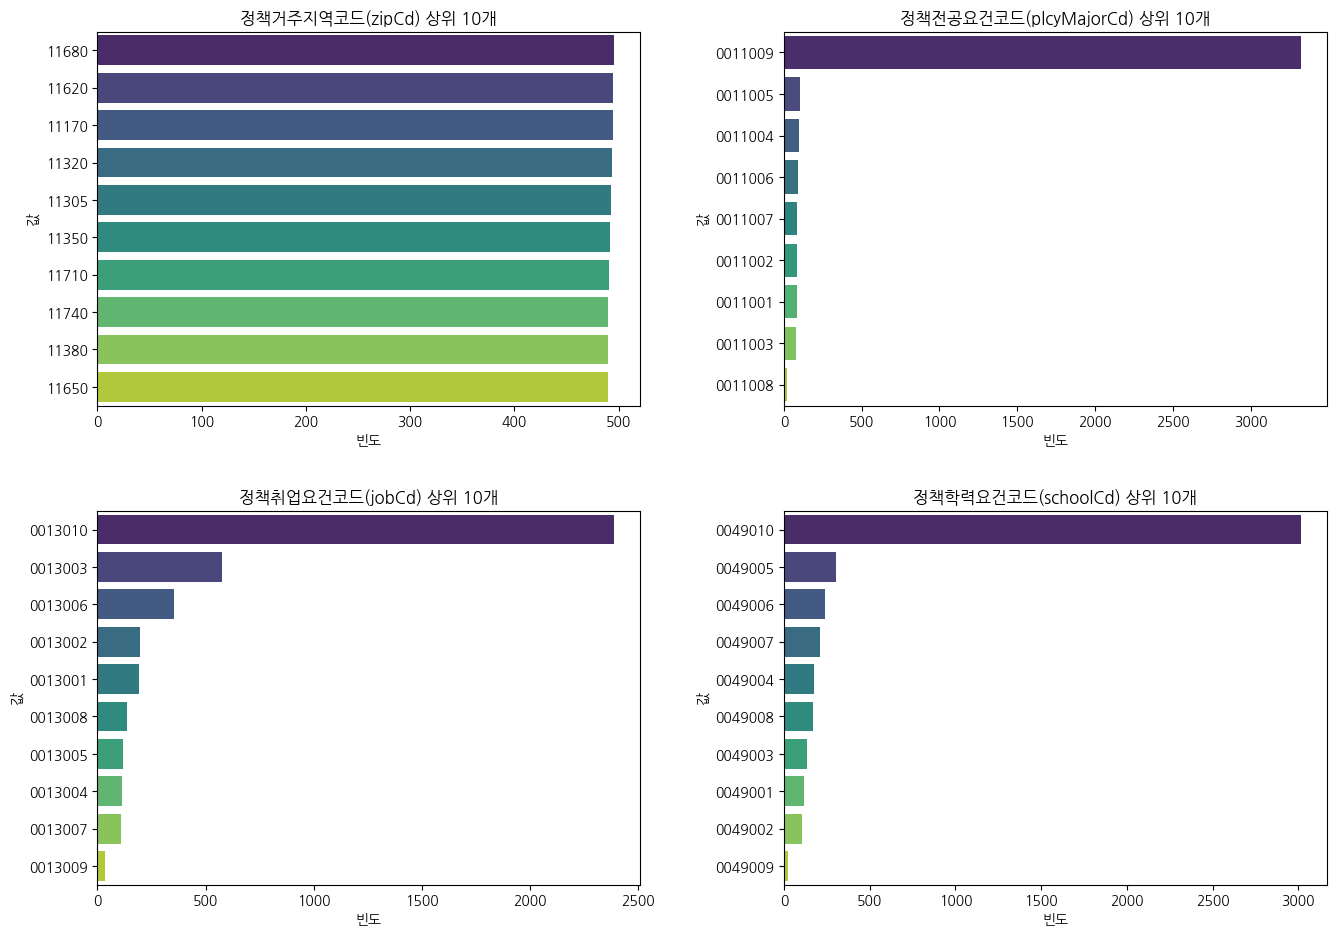


각 컬럼별 고유 값 수:
zipCd: 279
plcyMajorCd: 9
jobCd: 10
schoolCd: 10


In [115]:
# 쉼표로 구분된 값들을 분리하고 각각 카운트하는 함수
def count_comma_separated_values(series):
    # 결측치 제외하고 쉼표로 분리
    all_values = series.dropna().str.split(',').explode().str.strip()
    # 카운트
    value_counts = all_values.value_counts().reset_index()
    value_counts.columns = ['값', '빈도']
    return value_counts

# 각 컬럼별로 분리된 값 카운트
zipCd_counts = count_comma_separated_values(df['zipCd'])
plcyMajorCd_counts = count_comma_separated_values(df['plcyMajorCd'])
jobCd_counts = count_comma_separated_values(df['jobCd'])
schoolCd_counts = count_comma_separated_values(df['schoolCd'])

# 결과 출력
print("정책거주지역코드(zipCd) 빈도:")
display(zipCd_counts.head(10))  # 상위 10개만 표시
print("\n정책전공요건코드(plcyMajorCd) 빈도:")
display(plcyMajorCd_counts.head(10))
print("\n정책취업요건코드(jobCd) 빈도:")
display(jobCd_counts.head(10))
print("\n정책학력요건코드(schoolCd) 빈도:")
display(schoolCd_counts.head(10))

# 시각화 - 각 코드별 상위 항목 시각화
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
if not zipCd_counts.empty:
    sns.barplot(x='빈도', y='값', data=zipCd_counts.head(10), palette='viridis')
    plt.title('정책거주지역코드(zipCd) 상위 10개')
    plt.tight_layout()

plt.subplot(2, 2, 2)
if not plcyMajorCd_counts.empty:
    sns.barplot(x='빈도', y='값', data=plcyMajorCd_counts.head(10), palette='viridis')
    plt.title('정책전공요건코드(plcyMajorCd) 상위 10개')
    plt.tight_layout()

plt.subplot(2, 2, 3)
if not jobCd_counts.empty:
    sns.barplot(x='빈도', y='값', data=jobCd_counts.head(10), palette='viridis')
    plt.title('정책취업요건코드(jobCd) 상위 10개')
    plt.tight_layout()

plt.subplot(2, 2, 4)
if not schoolCd_counts.empty:
    sns.barplot(x='빈도', y='값', data=schoolCd_counts.head(10), palette='viridis')
    plt.title('정책학력요건코드(schoolCd) 상위 10개')
    plt.tight_layout()

plt.tight_layout(pad=3.0)
plt.show()

# 각 컬럼별 고유 값의 수 확인
print("\n각 컬럼별 고유 값 수:")
print(f"zipCd: {len(zipCd_counts)}")
print(f"plcyMajorCd: {len(plcyMajorCd_counts)}")
print(f"jobCd: {len(jobCd_counts)}")
print(f"schoolCd: {len(schoolCd_counts)}")

In [116]:
# 각 컬럼별 비결측치 개수와 고유 값 수 확인
print("\n각 컬럼별 통계:")
for column in ['zipCd', 'plcyMajorCd', 'jobCd', 'schoolCd']:
    # 비결측치 개수
    non_null_count = df[column].notna().sum()
    # 고유 값 수 (쉼표로 구분된 값 분리 전)
    unique_count_before = df[column].nunique()
    # 쉼표로 구분된 값 분리 후 고유 값 수
    unique_values = count_comma_separated_values(df[column])
    
    print(f"\n{column}:")
    print(f"  - 비결측치 개수: {non_null_count}/{len(df)} ({non_null_count/len(df)*100:.2f}%)")
    print(f"  - 쉼표 분리 전 고유 값 수: {unique_count_before}")
    print(f"  - 쉼표 분리 후 고유 값 수: {len(unique_values)}")
    
    # 각 컬럼별 상위 5개 값과 빈도
    if not unique_values.empty:
        print("  - 상위 5개 값과 빈도:")
        for i, row in unique_values.head(5).iterrows():
            print(f"      {row['값']}: {row['빈도']}개")


각 컬럼별 통계:

zipCd:
  - 비결측치 개수: 3458/3458 (100.00%)
  - 쉼표 분리 전 고유 값 수: 246
  - 쉼표 분리 후 고유 값 수: 279
  - 상위 5개 값과 빈도:
      11680: 496개
      11620: 495개
      11170: 495개
      11320: 494개
      11305: 493개

plcyMajorCd:
  - 비결측치 개수: 3458/3458 (100.00%)
  - 쉼표 분리 전 고유 값 수: 14
  - 쉼표 분리 후 고유 값 수: 9
  - 상위 5개 값과 빈도:
      0011009: 3322개
      0011005: 102개
      0011004: 95개
      0011006: 89개
      0011007: 87개

jobCd:
  - 비결측치 개수: 3458/3458 (100.00%)
  - 쉼표 분리 전 고유 값 수: 69
  - 쉼표 분리 후 고유 값 수: 10
  - 상위 5개 값과 빈도:
      0013010: 2392개
      0013003: 577개
      0013006: 354개
      0013002: 198개
      0013001: 193개

schoolCd:
  - 비결측치 개수: 3458/3458 (100.00%)
  - 쉼표 분리 전 고유 값 수: 66
  - 쉼표 분리 후 고유 값 수: 10
  - 상위 5개 값과 빈도:
      0049010: 3014개
      0049005: 304개
      0049006: 238개
      0049007: 212개
      0049004: 178개
